# 02 Monte Carlo para aproximar $\pi$

En este notebook usaremos azar para aproximar una cantidad matematica conocida: el numero $\pi$.

La idea es simple: lanzamos muchos puntos al azar en un cuadrado y contamos cuantos caen dentro de un circulo.


## Definiciones simples

- **Aleatorio**: generado al azar.
- **Simulacion**: experimento hecho con el computador.
- **Funcion**: bloque de codigo reutilizable.
- **Variable**: nombre que guarda un valor.
- **Error absoluto**: diferencia entre la aproximacion y el valor real.
- **Metodo de Monte Carlo**: metodo numerico que usa azar y muchas repeticiones para aproximar una cantidad.


## Idea matematica

Trabajamos en el cuadrado $[-1,1] \times [-1,1]$, que tiene area $4$.

Dentro de ese cuadrado esta el circulo de radio $1$, cuya area es $\pi$.

Si la proporcion de puntos dentro del circulo es aproximadamente $\pi/4$, entonces:

$$\pi \approx 4 \cdot \frac{\text{puntos dentro}}{\text{puntos totales}}$$


In [6]:
# math contiene el valor real de pi para comparar.
import math

# numpy nos permite generar muchos numeros aleatorios de manera eficiente.
import numpy as np

# matplotlib sirve para dibujar graficos.
import matplotlib.pyplot as plt


In [7]:
def simular_pi(n, semilla=42):
    """Aproxima pi usando n puntos aleatorios en el cuadrado [-1,1]x[-1,1]."""

    # Fijamos una semilla para que el experimento se pueda repetir.
    rng = np.random.default_rng(semilla)

    # Generamos n coordenadas x y n coordenadas y entre -1 y 1.
    x = rng.uniform(-1, 1, n)
    y = rng.uniform(-1, 1, n)

    # Esta condicion revisa si cada punto cumple x^2 + y^2 <= 1.
    # Si se cumple, el punto esta dentro del circulo.
    dentro = x**2 + y**2 <= 1

    # dentro es un arreglo de True/False. Su promedio es la proporcion de exitos.
    proporcion_dentro = dentro.mean()

    # Como la proporcion aproxima pi/4, multiplicamos por 4.
    pi_aprox = 4 * proporcion_dentro

    # Calculamos el error absoluto para medir que tan lejos estamos del valor real.
    error_abs = abs(pi_aprox - math.pi)

    return {
        "n": n,
        "pi_aprox": pi_aprox,
        "error_abs": error_abs,
        "x": x,
        "y": y,
        "dentro": dentro,
    }


In [8]:
# Probamos distintos tamanos de muestra para ver la convergencia.
muestras = [100, 1000, 10_000, 100_000]
resultados = [simular_pi(n, semilla=42) for n in muestras]

# Mostramos un resumen simple sin usar librerias extra.
print("n".ljust(12), "pi_aprox".ljust(16), "error_abs")
print("-" * 40)
for r in resultados:
    print(str(r["n"]).ljust(12), f"{r['pi_aprox']:.8f}".ljust(16), f"{r['error_abs']:.8f}")


n            pi_aprox         error_abs
----------------------------------------
100          3.12000000       0.02159265
1000         3.08000000       0.06159265
10000        3.12560000       0.01599265
100000       3.14308000       0.00148735


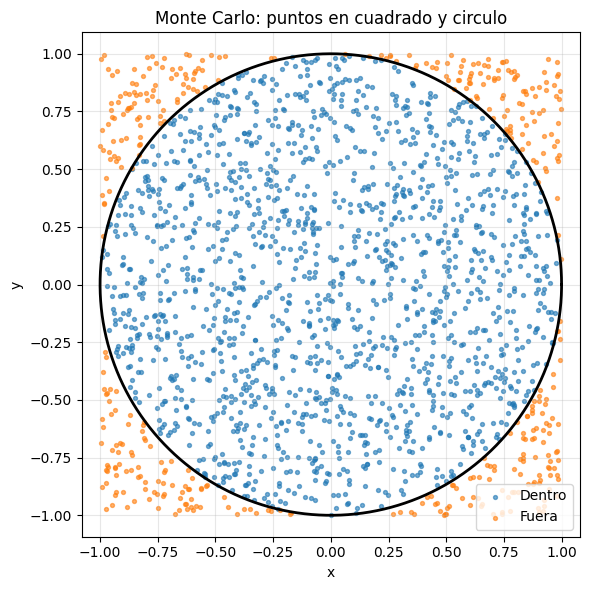

In [9]:
# Elegimos un experimento intermedio para visualizar los puntos.
r = simular_pi(2000, semilla=7)

plt.figure(figsize=(6, 6))

# Dibujamos en azul los puntos dentro del circulo.
plt.scatter(r["x"][r["dentro"]], r["y"][r["dentro"]], s=8, alpha=0.6, label="Dentro")

# Dibujamos en naranja los puntos fuera del circulo.
plt.scatter(r["x"][~r["dentro"]], r["y"][~r["dentro"]], s=8, alpha=0.6, label="Fuera")

# theta es una lista de angulos para dibujar la frontera del circulo.
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), color="black", linewidth=2)

plt.title("Monte Carlo: puntos en cuadrado y circulo")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


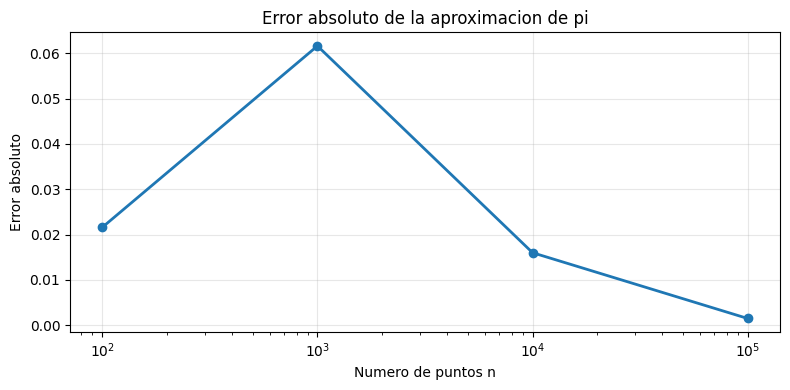

Valor real de pi: 3.141592653589793
Mejor aproximacion de esta tabla: 3.14308000


In [10]:
# Construimos listas con los valores de n y con los errores de cada experimento.
valores_n = [r["n"] for r in resultados]
errores = [r["error_abs"] for r in resultados]

plt.figure(figsize=(8, 4))
plt.plot(valores_n, errores, marker="o", linewidth=2)

# Usamos escala logaritmica para apreciar mejor el cambio cuando n crece mucho.
plt.xscale("log")
plt.title("Error absoluto de la aproximacion de pi")
plt.xlabel("Numero de puntos n")
plt.ylabel("Error absoluto")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mejor = min(resultados, key=lambda r: r["error_abs"])
print(f"Valor real de pi: {math.pi}")
print(f"Mejor aproximacion de esta tabla: {mejor['pi_aprox']:.8f}")


## Preguntas para discutir

1. Que cambia cuando pasas de 100 a 100000 puntos?
2. Por que el metodo mejora cuando aumenta `n`?
3. Por que la mejora no es perfectamente monotona?
4. Que ventaja tiene usar una simulacion para aproximar una cantidad matematica?
